In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import mlgw_bns
from mlgw_bns import ParametersWithExtrinsic
from mlgw_bns.jax_predict import model_to_jax_waveform
from jax_export import export_model
from jax_import_n_predict import load_predict
import timeit

# ── Export model ──────────────────────────────────────────────────────
model = mlgw_bns.Model.default()
export_model(model, "mlgw_bns_jax_model.h5")

/workspaces/mlgw_bns_jax/mlgw_bns/model.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Model exported to mlgw_bns_jax_model.h5


/opt/conda/envs/py311/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/envs/py311/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.1.2 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# ── Build both predictors ─────────────────────────────────────────────
predict_orig = jax.jit(model_to_jax_waveform(model))
predict_standalone = jax.jit(load_predict("mlgw_bns_jax_model.h5"))

# ── Shared parameters ────────────────────────────────────────────────
params = jnp.array([1.1, 300.0, 300.0, 0.1, 0.1])
freqs  = jnp.linspace(20., 2048., 2000)
M_tot  = jnp.array(2.8)
dist   = jnp.array(100.0)
iota   = jnp.array(0.0)

# ── Warm-up (JIT compilation) ────────────────────────────────────────
_ = predict_orig(params, freqs, M_tot, dist, iota)
_ = predict_standalone(params, freqs, M_tot, dist, iota)
print("JIT warm-up done.")

JIT warm-up done.


In [3]:
# ── Timing: single call ───────────────────────────────────────────────
N = 500

def call_orig():
    hp, hc = predict_orig(params, freqs, M_tot, dist, iota)
    hp.block_until_ready()

def call_standalone():
    hp, hc = predict_standalone(params, freqs, M_tot, dist, iota)
    hp.block_until_ready()

t_orig = timeit.timeit(call_orig, number=N) / N
t_standalone = timeit.timeit(call_standalone, number=N) / N

print(f"Original (jax_predict.py):        {t_orig*1e3:.3f} ms")
print(f"Standalone (jax_import_n_predict): {t_standalone*1e3:.3f} ms")
print(f"Ratio (standalone / original):     {t_standalone/t_orig:.3f}")

Original (jax_predict.py):        1.107 ms
Standalone (jax_import_n_predict): 0.769 ms
Ratio (standalone / original):     0.695


In [4]:
hp_orig, hc_orig = predict_orig(params, freqs, M_tot, dist, iota)

In [5]:
hp_sa, hc_sa = predict_standalone(params, freqs, M_tot, dist, iota)

In [6]:
import matplotlib.pyplot as plt

/opt/conda/envs/py311/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/conda/envs/py311/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


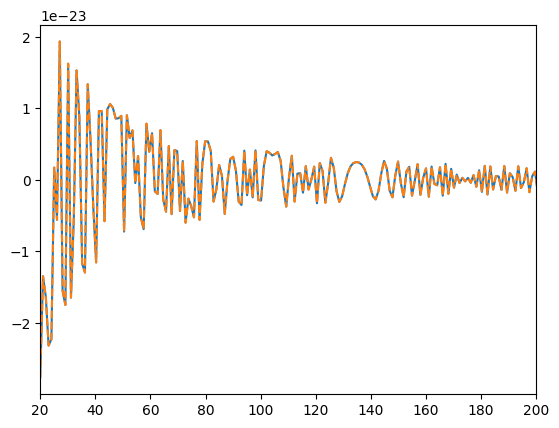

In [8]:
plt.plot(freqs, hp_orig, label="Original")
plt.plot(freqs, hp_sa, label="Standalone", linestyle="dashed")
plt.xlim(20,200)
plt.show()

batch=  1  orig=0.79 ms  standalone=0.73 ms  ratio=0.921
batch=  2  orig=1.52 ms  standalone=1.48 ms  ratio=0.974
batch=  4  orig=3.00 ms  standalone=2.52 ms  ratio=0.838
batch=  8  orig=4.36 ms  standalone=5.67 ms  ratio=1.301
batch= 16  orig=8.01 ms  standalone=8.47 ms  ratio=1.058
batch= 32  orig=15.47 ms  standalone=18.45 ms  ratio=1.193
batch= 64  orig=34.67 ms  standalone=28.80 ms  ratio=0.831
batch=128  orig=79.24 ms  standalone=60.39 ms  ratio=0.762
batch=256  orig=133.21 ms  standalone=133.11 ms  ratio=0.999


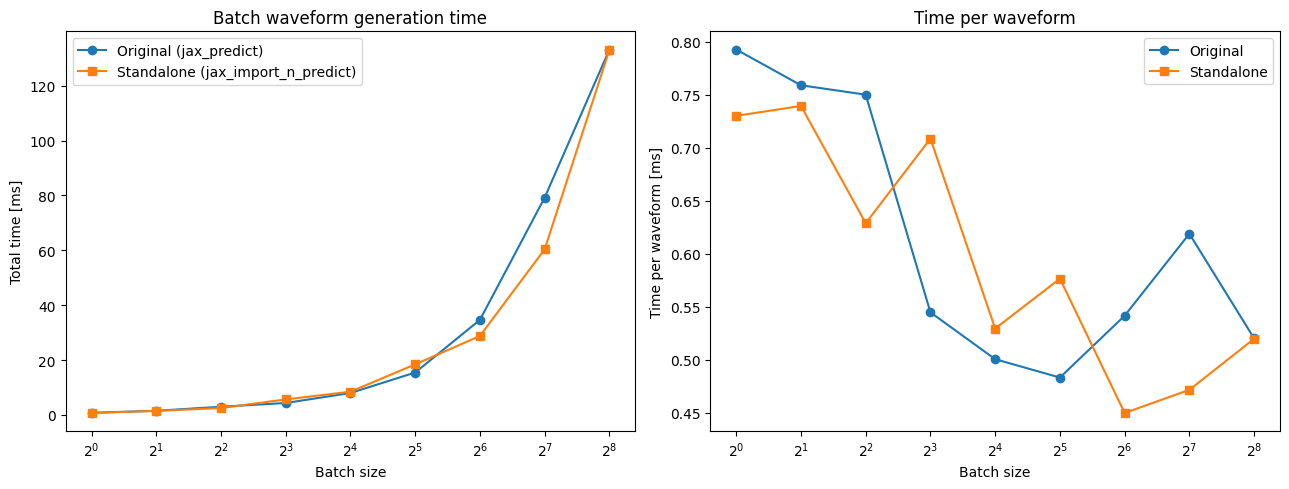

In [4]:
# ── Timing: vmap batch ────────────────────────────────────────────────
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
base = np.array([1.1, 300.0, 300.0, 0.1, 0.1])
all_params = jnp.array(base + rng.uniform(-0.05, 0.05, size=(256, 5)) * base)

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
t_orig_batch = []
t_stand_batch = []

for N_batch in batch_sizes:
    batch = all_params[:N_batch]

    vmap_orig = jax.jit(jax.vmap(lambda p: predict_orig(p, freqs, M_tot, dist, iota)))
    vmap_stand = jax.jit(jax.vmap(lambda p: predict_standalone(p, freqs, M_tot, dist, iota)))

    # warm-up
    vmap_orig(batch)[0].block_until_ready()
    vmap_stand(batch)[0].block_until_ready()

    t_o = timeit.timeit(lambda: vmap_orig(batch)[0].block_until_ready(), number=100) / 100
    t_s = timeit.timeit(lambda: vmap_stand(batch)[0].block_until_ready(), number=100) / 100
    t_orig_batch.append(t_o * 1e3)
    t_stand_batch.append(t_s * 1e3)
    print(f"batch={N_batch:3d}  orig={t_o*1e3:.2f} ms  standalone={t_s*1e3:.2f} ms  ratio={t_s/t_o:.3f}")

# ── Plot ─────────────────────────────────────────────────────────────
bs = np.array(batch_sizes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(bs, np.array(t_orig_batch), "o-", label="Original (jax_predict)")
ax1.plot(bs, np.array(t_stand_batch), "s-", label="Standalone (jax_import_n_predict)")
ax1.set_xlabel("Batch size")
ax1.set_ylabel("Total time [ms]")
ax1.set_xscale("log", base=2)
ax1.set_title("Batch waveform generation time")
ax1.legend()

ax2.plot(bs, np.array(t_orig_batch) / bs, "o-", label="Original")
ax2.plot(bs, np.array(t_stand_batch) / bs, "s-", label="Standalone")
ax2.set_xlabel("Batch size")
ax2.set_ylabel("Time per waveform [ms]")
ax2.set_xscale("log", base=2)
ax2.set_title("Time per waveform")
ax2.legend()

plt.tight_layout()
plt.show()

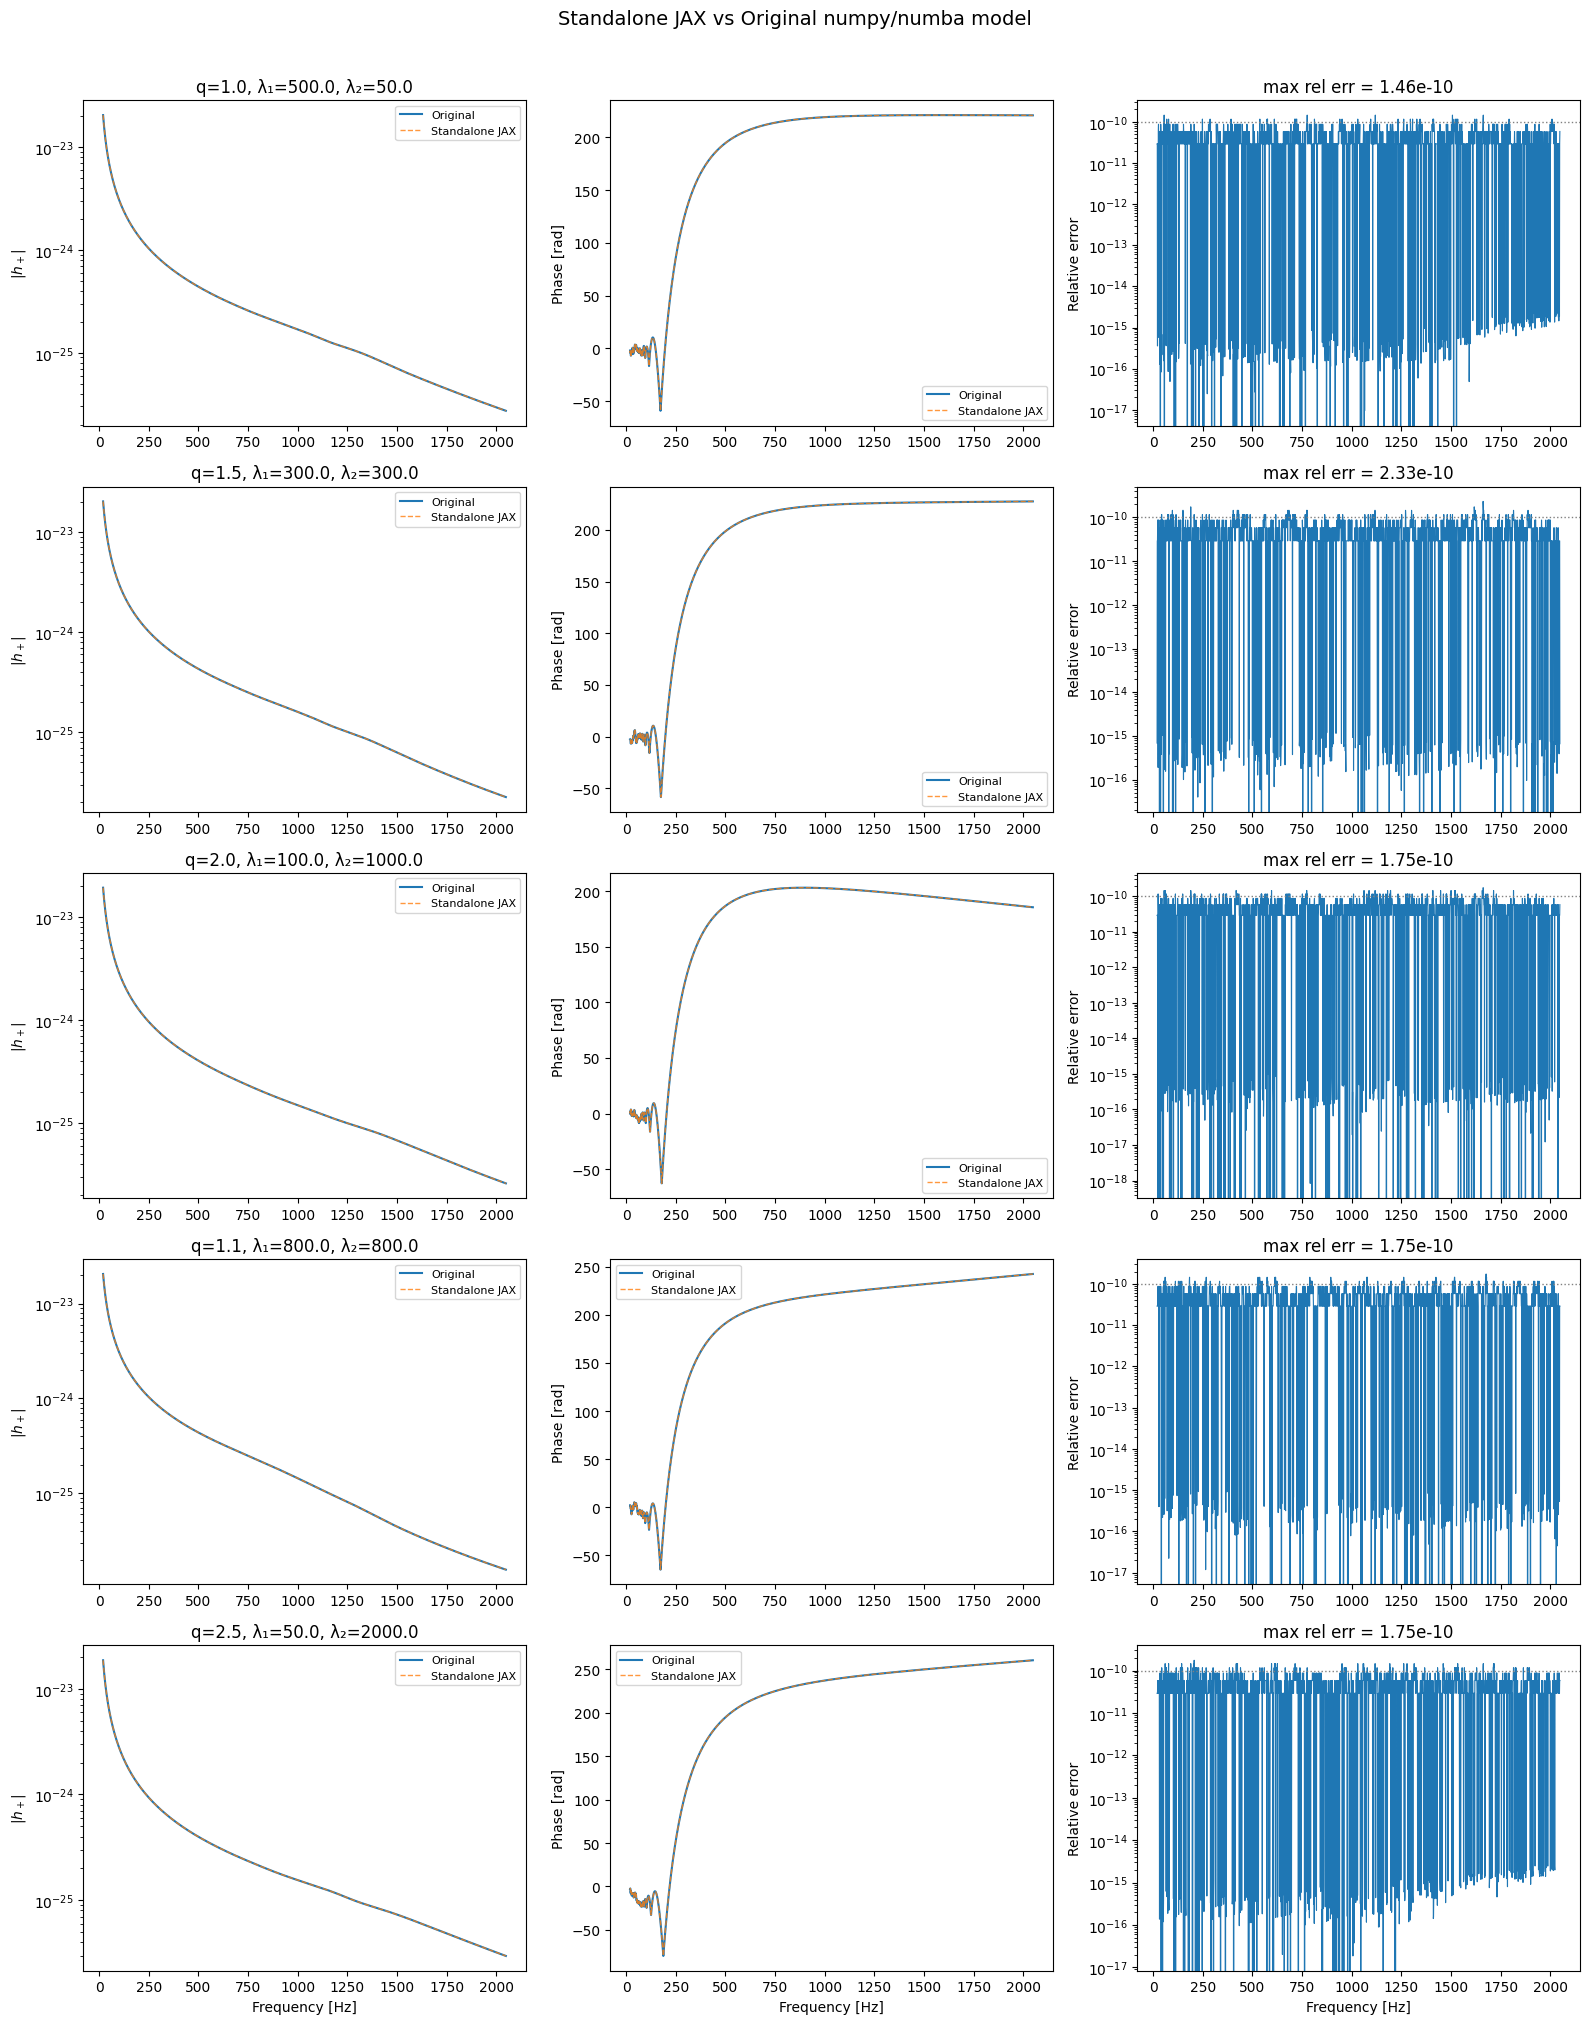

In [5]:
# ── Accuracy: standalone JAX vs original numpy/numba model.predict ────
import matplotlib.pyplot as plt

# Test across several parameter sets
param_sets = [
    dict(q=1.0, lam1=500.0, lam2=50.0,  chi1=0.1,  chi2=-0.1),
    dict(q=1.5, lam1=300.0, lam2=300.0, chi1=0.0,  chi2=0.0),
    dict(q=2.0, lam1=100.0, lam2=1000.0,chi1=-0.3, chi2=0.3),
    dict(q=1.1, lam1=800.0, lam2=800.0, chi1=0.05, chi2=-0.05),
    dict(q=2.5, lam1=50.0,  lam2=2000.0,chi1=0.4,  chi2=-0.4),
]

M_test, d_test, iota_test = 2.8, 100.0, 0.8
freqs_np = np.linspace(20.0, 2048.0, num=2000)
freqs_jax = jnp.array(freqs_np)

fig, axes = plt.subplots(len(param_sets), 3, figsize=(16, 4 * len(param_sets)))

for row, pdict in enumerate(param_sets):
    # ── JAX standalone ──
    pj = jnp.array([pdict["q"], pdict["lam1"], pdict["lam2"], pdict["chi1"], pdict["chi2"]])
    hp_jax, hc_jax = predict_standalone(pj, freqs_jax,
                                         jnp.array(M_test), jnp.array(d_test), jnp.array(iota_test))
    hp_j = np.array(hp_jax)

    # ── Original numpy/numba ──
    p_ext = ParametersWithExtrinsic(
        mass_ratio=pdict["q"], lambda_1=pdict["lam1"], lambda_2=pdict["lam2"],
        chi_1=pdict["chi1"], chi_2=pdict["chi2"],
        distance_mpc=d_test, inclination=iota_test, total_mass=M_test,
    )
    hp_ref, _ = model.predict(freqs_np, p_ext)
    hp_r = np.array(hp_ref)

    # ── Amplitude comparison ──
    amp_j = np.abs(hp_j)
    amp_r = np.abs(hp_r)
    axes[row, 0].semilogy(freqs_np, amp_r, label="Original", lw=1.5)
    axes[row, 0].semilogy(freqs_np, amp_j, "--", label="Standalone JAX", lw=1, alpha=0.8)
    axes[row, 0].set_ylabel(r"$|h_+|$")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].set_title(f"q={pdict['q']}, λ₁={pdict['lam1']}, λ₂={pdict['lam2']}")

    # ── Phase comparison ──
    phase_j = np.unwrap(np.angle(hp_j))
    phase_r = np.unwrap(np.angle(hp_r))
    axes[row, 1].plot(freqs_np, phase_r, label="Original", lw=1.5)
    axes[row, 1].plot(freqs_np, phase_j, "--", label="Standalone JAX", lw=1, alpha=0.8)
    axes[row, 1].set_ylabel("Phase [rad]")
    axes[row, 1].legend(fontsize=8)

    # ── Relative error ──
    rel_err = np.abs(hp_j - hp_r) / (np.abs(hp_r) + 1e-60)
    axes[row, 2].semilogy(freqs_np, rel_err, lw=0.8)
    axes[row, 2].axhline(1e-10, color="gray", ls=":", lw=1)
    axes[row, 2].set_ylabel("Relative error")
    axes[row, 2].set_title(f"max rel err = {rel_err.max():.2e}")

for ax in axes[-1]:
    ax.set_xlabel("Frequency [Hz]")

plt.suptitle("Standalone JAX vs Original numpy/numba model", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()